# Running Reproducible Experiments with YAML Configs

VISTA includes a **YAML-driven experiment runner** that lets you define
batches of VISTA generation jobs in a declarative configuration file.
This notebook walks through the three config patterns — *baseline*,
*sweep*, and *multi-param* — and shows how to run experiments, inspect
results, and visualise the outputs.

## Setup

In [1]:
import json
import shutil
import sys
from pathlib import Path

# Add the mcda-vista root so the experiments package can be imported
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import yaml

from experiments.run_experiments import load_config, build_jobs, run_experiment
from mcda_vista.core import VistaResult, generate_vista
from mcda_vista.io import save_vista, load_vista
from mcda_vista.plotting import plot_vista, plot_vista_comparison

%matplotlib inline

## Understanding Experiment Configs

Every YAML config starts with common metadata fields:

| Field | Purpose |
|---|---|
| `experiment` | Short identifier (used as output directory name) |
| `description` | Human-readable description of the experiment |
| `resolution` | Grid points per criterion axis (e.g. 101) |
| `n_criteria` | Number of criteria (2 or 3) |
| `reference` | Reference alternative coordinates |
| `weights` | Criteria weight vector |

The *job-generating* section uses one of three patterns:

1. **Simple (baseline)** — `methods:` maps method names → parameter dicts.  
   One job per method.
2. **Sweep** — `sweep:` with a single key (`weights`, `reference`, or
   `third_alternative`) listing values to iterate over, combined with
   `methods:`.  One job per (sweep-value × method) combination.
3. **Multi-param** — `method_sweeps:` with per-method `sweep:` + `base:`
   parameter dicts.  A Cartesian product of swept parameter values
   is generated for each method independently.

## Examining a Baseline Config

The `baseline.yaml` config defines one job per method using default parameters.

In [2]:
cfg = load_config("../experiments/configs/baseline.yaml")
print(yaml.dump(cfg, default_flow_style=False))

description: Baseline VISTAs for all methods with default parameters
experiment: baseline
methods:
  assess:
    delta: 0.1
    form: L
    k: 5
  borda: {}
  electre_iii:
    alpha: -0.15
    beta: 0.3
    p: 0.2
    q: 0.1
    v: 1.0
  electre_iiic:
    lamb: 0.6
    p: 0.2
    q: 0.1
    v: 1.0
  etopsis:
    aggregation: R
    delta: 0.1
    epsilon: 1.0
  macbeth:
    delta: 0.1
  oreste:
    alpha: 0.4
  promethee_i:
    f: t4
    p: 0.2
    q: 0.1
    s: 0.0
  regime: {}
  saw:
    delta: 0.1
  spotis:
    delta: 0.1
  topsis:
    delta: 0.1
  uta:
    delta: 0.1
    form: L
    k: 5
  vikor:
    v: 0.5
n_criteria: 2
reference:
- 0.5
- 0.5
resolution: 101
weights:
- 1.0
- 1.0



In [3]:
jobs = build_jobs(cfg)
print(f"{len(jobs)} jobs generated from baseline config\n")

for i, job in enumerate(jobs[:5], 1):
    params_str = ", ".join(f"{k}={v}" for k, v in job["method_params"].items())
    print(f"  [{i}] {job['label']:20s}  params: {params_str or '(none)'}")

if len(jobs) > 5:
    print(f"  ... and {len(jobs) - 5} more")

14 jobs generated from baseline config

  [1] saw                   params: delta=0.1
  [2] topsis                params: delta=0.1
  [3] etopsis               params: aggregation=R, epsilon=1.0, delta=0.1
  [4] borda                 params: (none)
  [5] oreste                params: alpha=0.4
  ... and 9 more


## Running a Small Experiment

Instead of writing a YAML file, we can pass a Python dict directly to
`run_experiment`.  Let's create a tiny config with 3 methods and
resolution 51 so it finishes quickly.

In [4]:
mini_cfg = {
    "experiment": "mini_demo",
    "description": "Quick demo with 3 methods",
    "resolution": 51,
    "n_criteria": 2,
    "reference": [0.5, 0.5],
    "weights": [1.0, 1.0],
    "methods": {
        "topsis": {"delta": 0.10},
        "saw": {"delta": 0.10},
        "vikor": {"v": 0.50},
    },
}

output_demo = Path("output_demo")
run_experiment(mini_cfg, output_demo, make_plots=True)

Experiment : mini_demo
Description: Quick demo with 3 methods
Resolution : 51
Jobs       : 3
Output     : output_demo\mini_demo

  [  1/3] topsis ... 

done (4.7s)
  [  2/3] saw ... 

done (0.5s)
  [  3/3] vikor ... 

done (1.0s)

Done. Summary saved to output_demo\mini_demo\experiment_summary.json


In [5]:
# List generated output files
exp_dir = output_demo / "mini_demo"
for p in sorted(exp_dir.iterdir()):
    print(f"  {p.name:40s}  ({p.stat().st_size:,} bytes)")

  experiment_summary.json                   (1,239 bytes)
  saw.csv                                   (54,637 bytes)
  saw.meta.json                             (213 bytes)
  saw.png                                   (30,686 bytes)
  saw_meta.json                             (272 bytes)
  topsis.csv                                (54,637 bytes)
  topsis.meta.json                          (216 bytes)
  topsis.png                                (30,987 bytes)
  topsis_meta.json                          (278 bytes)
  vikor.csv                                 (54,637 bytes)
  vikor.meta.json                           (211 bytes)
  vikor.png                                 (30,469 bytes)
  vikor_meta.json                           (272 bytes)


## Sweep Configs

A *sweep* config varies one global dimension (e.g. `weights`) across
a list of values while keeping all method-specific parameters fixed.
Each (sweep-value, method) pair becomes its own job.

In [6]:
cfg_weights = load_config("../experiments/configs/weights.yaml")
print(yaml.dump(cfg_weights, default_flow_style=False))

description: Influence of criteria weights on VISTAs
experiment: weights_sweep
methods:
  electre_iii:
    alpha: -0.15
    beta: 0.3
    p: 0.2
    q: 0.1
    v: 1.0
  electre_iiic:
    lamb: 0.6
    p: 0.2
    q: 0.1
    v: 1.0
  etopsis:
    aggregation: R
    delta: 0.1
    epsilon: 1.0
  oreste:
    alpha: 0.4
  promethee_i:
    f: t4
    p: 0.2
    q: 0.1
    s: 0.0
  regime: {}
  saw:
    delta: 0.1
  topsis:
    delta: 0.1
n_criteria: 2
reference:
- 0.5
- 0.5
resolution: 101
sweep:
  weights:
  - - 0.25
    - 0.75
  - - 0.25
    - 0.5
  - - 0.5
    - 0.5
  - - 0.5
    - 0.25
  - - 0.75
    - 0.25



In [7]:
jobs_weights = build_jobs(cfg_weights)
print(f"{len(jobs_weights)} jobs in weights sweep\n")

# Show a sample of labels to see the sweep × method combinations
for i, job in enumerate(jobs_weights[:10], 1):
    print(f"  [{i:2d}] {job['label']}")

if len(jobs_weights) > 10:
    print(f"  ... and {len(jobs_weights) - 10} more")

print("\n(Sweep configs can be large — dry-run first to verify job count.)")

40 jobs in weights sweep

  [ 1] saw__weights=0.25_0.75
  [ 2] topsis__weights=0.25_0.75
  [ 3] etopsis__weights=0.25_0.75
  [ 4] oreste__weights=0.25_0.75
  [ 5] promethee_i__weights=0.25_0.75
  [ 6] regime__weights=0.25_0.75
  [ 7] electre_iii__weights=0.25_0.75
  [ 8] electre_iiic__weights=0.25_0.75
  [ 9] saw__weights=0.25_0.5
  [10] topsis__weights=0.25_0.5
  ... and 30 more

(Sweep configs can be large — dry-run first to verify job count.)


## Multi-Param Configs

The `method_sweeps` pattern lets each method define its own parameter
grid.  Jobs are the Cartesian product of each method's `sweep:` axes,
combined with its `base:` parameters.

In [8]:
cfg_multi = load_config("../experiments/configs/multi_param.yaml")
print(yaml.dump(cfg_multi, default_flow_style=False))

description: Method-specific parameter sweeps
experiment: multi_param
method_sweeps:
  electre_iii:
    base:
      alpha: -0.15
      beta: 0.3
      v: 1.0
    sweep:
      p:
      - 0.0
      - 0.1
      - 0.2
      q:
      - 0.0
      - 0.1
      - 0.2
  electre_iiic:
    base:
      lamb: 0.6
      v: 1.0
    sweep:
      p:
      - 0.0
      - 0.1
      - 0.2
      q:
      - 0.0
      - 0.1
      - 0.2
  etopsis:
    base:
      aggregation: R
    sweep:
      delta:
      - 0.0
      - 0.1
      - 0.2
      epsilon:
      - 0.67
      - 1.0
      - 1.5
  oreste:
    sweep:
      alpha:
      - 0.3
      - 0.35
      - 0.4
      - 0.45
      - 0.5
  promethee_i:
    base:
      f: t4
      s: 0.0
    sweep:
      p:
      - 0.0
      - 0.1
      - 0.2
      q:
      - 0.0
      - 0.1
      - 0.2
  saw:
    sweep:
      delta:
      - 0.0
      - 0.05
      - 0.1
      - 0.15
      - 0.2
  topsis:
    sweep:
      delta:
      - 0.0
      - 0.05
      - 0.1
      - 0.15
      -

In [9]:
jobs_multi = build_jobs(cfg_multi)
print(f"{len(jobs_multi)} jobs in multi-param sweep\n")

# Show a few labels per method
seen_methods = set()
for job in jobs_multi:
    method = job["method"]
    if method not in seen_methods:
        seen_methods.add(method)
        count = sum(1 for j in jobs_multi if j["method"] == method)
        print(f"  {method}: {count} jobs")

print("\nFirst 8 job labels:")
for i, job in enumerate(jobs_multi[:8], 1):
    print(f"  [{i}] {job['label']}")

56 jobs in multi-param sweep

  saw: 5 jobs
  topsis: 5 jobs
  etopsis: 9 jobs
  oreste: 5 jobs
  promethee_i: 9 jobs
  electre_iii: 9 jobs
  electre_iiic: 9 jobs
  vikor: 5 jobs

First 8 job labels:
  [1] saw__delta=0
  [2] saw__delta=0.05
  [3] saw__delta=0.1
  [4] saw__delta=0.15
  [5] saw__delta=0.2
  [6] topsis__delta=0
  [7] topsis__delta=0.05
  [8] topsis__delta=0.1


## Loading and Plotting Experiment Results

After running the mini experiment above, we can reload the saved CSV
results via `load_vista()`, reconstruct `VistaResult` objects, and
produce a comparison plot.

In [10]:
# Read the experiment summary to discover which jobs succeeded
summary_path = exp_dir / "experiment_summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8"))
print(f"Experiment: {summary['experiment']}")
print(f"Total jobs: {summary['total_jobs']}, failed: {summary['failed_jobs']}")

Experiment: mini_demo
Total jobs: 3, failed: 0


In [11]:
# Reload each successful result and reconstruct VistaResult objects
results = []
for job_meta in summary["jobs"]:
    if "error" in job_meta:
        continue
    label = job_meta["label"]
    data = load_vista(exp_dir / label)
    vr = VistaResult(
        grid=data["grid"],
        relations=data["relations"],
        reference=data["reference"],
        weights=data["weights"],
        method_name=data["method_name"],
        params=data["params"],
        resolution=data["resolution"],
        n_criteria=data["grid"].shape[1],
    )
    results.append(vr)

print(f"Loaded {len(results)} results: {[r.method_name for r in results]}")

Loaded 3 results: ['topsis', 'saw', 'vikor']


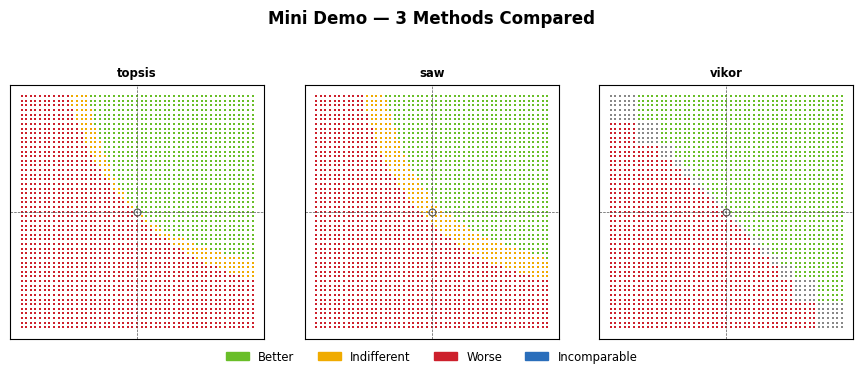

In [12]:
fig = plot_vista_comparison(
    results,
    ncols=3,
    title="Mini Demo — 3 Methods Compared",
    point_size=1.0,
)
fig.set_size_inches(9, 3.5)

## Cleanup

Remove the demo output directory created during this notebook.

In [13]:
shutil.rmtree(output_demo, ignore_errors=True)
print("Cleaned up output_demo/")

Cleaned up output_demo/


## Summary

This notebook demonstrated the YAML-driven experiment runner:

| Pattern | Config key | Use case |
|---|---|---|
| **Baseline** | `methods:` | One job per method, fixed params |
| **Sweep** | `sweep:` + `methods:` | Vary one global dimension (weights, reference, third alternative) |
| **Multi-param** | `method_sweeps:` | Per-method Cartesian parameter grids |

**Key functions:**

- `load_config(path)` — parse and validate a YAML config file
- `build_jobs(cfg)` — generate the list of jobs (useful for dry-run inspection)
- `run_experiment(cfg, output_dir)` — execute all jobs and save results + summary
- `load_vista(path)` — reload a saved result for further analysis

All five experiment configs in `experiments/configs/` (`baseline.yaml`,
`weights.yaml`, `refpoints.yaml`, `third_alt.yaml`, `multi_param.yaml`)
can be run from the command line:

```bash
python -m experiments.run_experiments experiments/configs/baseline.yaml --plot
```